In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

_ROOT = Path('..').resolve()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from astropy.table import Table
from astropy.cosmology import Planck18
import numpy as np
import matplotlib.pyplot as plt

from recon_jax import sky_to_transverse_grid

/opt/miniconda3/envs/jax/lib/python3.12/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [7]:
# NB816 filter
lam_center = 8168.36
W = 111
z_c = lam_center/1216 - 1
z_lo = (lam_center - W/2)/1216 - 1
z_hi = (lam_center + W/2)/1216 - 1

Text(0.5, 1.0, 'LOS span=27 cMpc')

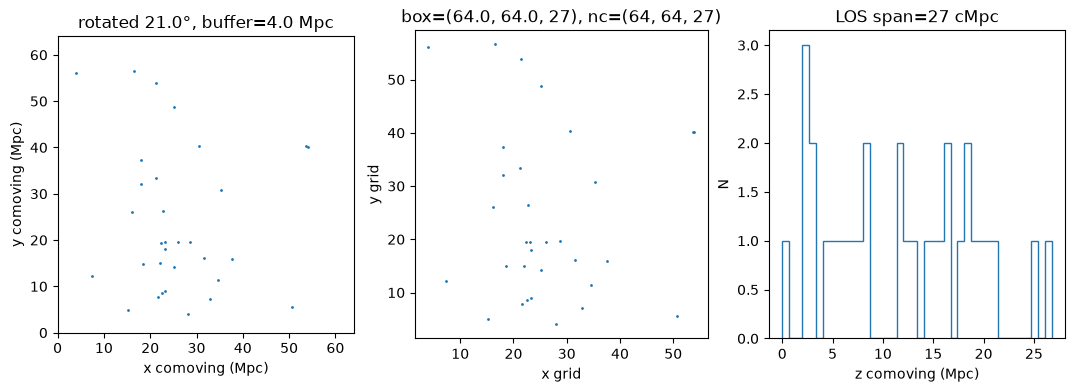

In [12]:
rotate_deg = 21.0
xy_buffer = 4.0   # x/y 方向共动距离 buffer (Mpc)
box_size = (64.0, 64.0, 27)  # (Lx, Ly, Lz) cMpc/h；Lz=None 时自动取 z_com 跨度
nc = (64, 64, 27) # number of cells

cat = Table.read('../../../good_hae_v1.fits')
ra = cat['RA']
dec = cat['DEC']
z_fit = cat['z_fit']
z_fit_err = cat['z_fit_err']

idx = (z_fit > z_lo) & (z_fit < z_hi)
cat = cat[idx]
coords = sky_to_transverse_grid(
    ra[idx], dec[idx], z_fit[idx],
    z_err=z_fit_err[idx],
    cosmo=Planck18,
    rotate_deg=rotate_deg,
    xy_buffer=xy_buffer,
    box_size=box_size,
    nc=nc,
)

cat['x_com'] = coords.x_com
cat['y_com'] = coords.y_com
cat['z_com'] = coords.z_com
cat['x_rot'] = coords.x_rot
cat['y_rot'] = coords.y_rot
cat['x_grid'] = coords.x_grid
cat['y_grid'] = coords.y_grid
cat['z_grid'] = coords.z_grid
cat['z_err_com'] = coords.z_err_com
cat['z_err_grid'] = coords.z_err_grid

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].scatter(coords.x_rot, coords.y_rot, s=1)
ax[0].set_xlabel('x comoving (Mpc)')
ax[0].set_ylabel('y comoving (Mpc)')
ax[0].set_aspect('equal')
ax[0].set_title(f'rotated {rotate_deg:.1f}°, buffer={xy_buffer} Mpc')
ax[0].set_xlim(0, box_size[0])
ax[0].set_ylim(0, box_size[1])
ax[1].scatter(coords.x_grid, coords.y_grid, s=1)
ax[1].set_xlabel('x grid')
ax[1].set_ylabel('y grid')
ax[1].set_aspect('equal')
ax[1].set_title(f'box={box_size}, nc={nc}')

ax[2].hist(coords.z_com, bins=40, histtype='step')
ax[2].set_xlabel('z comoving (Mpc)')
ax[2].set_ylabel('N')
ax[2].set_title(f'LOS span={coords.z_com.max():.0f} cMpc')

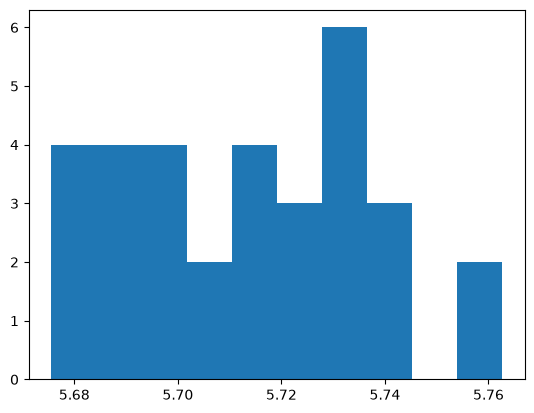

In [10]:
_ = plt.hist(cat['z_fit'])

In [14]:
from recon_jax import GalaxyCatalog, ReconConfig, Reconstructor, make_mock_catalog
from recon_jax.painting import galaxy_bias

In [15]:
xyz_grid = np.stack([coords.x_grid, coords.y_grid, coords.z_grid], axis=1)
catalog = GalaxyCatalog.from_arrays(xyz_grid, coords.z_err_com)
cfg_sim = ReconConfig(
    nc=nc, 
    box_size=box_size,
    z_init=30.0,
    z_final=5.7,
    n_body=True,
    b1=1,
    b2=0,
    galaxy_fac=1.0,
    prior_fac=0.3,
    redshift_fac=1.0,
    anneal_scales=(2.0, 1.0,0),
    maxiter=(20, 10, 20),
    fit_los=False,
    seed=0,
    los_axis=2,
)
rec_sim = Reconstructor(cfg_sim,likelihood="poisson")


print(f"catalog: {catalog.num_gal} galaxies on {box_size} grid, number density = {catalog.num_gal/np.prod(box_size):.4f} per Mpc^3")


/opt/miniconda3/envs/jax/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


catalog: 32 galaxies on (64.0, 64.0, 27) grid, number density = 0.0003 per Mpc^3


In [16]:
out_sim = rec_sim.run(catalog, seed=1)

[stage 0] R= 2.0 cells  loss 3.7248e+02 -> 2.9197e+02  (17.4s)
[stage 1] R= 1.0 cells  loss 2.9053e+02 -> 2.8956e+02  (33.2s)
[stage 2] R=   0 cells  loss 2.8374e+02 -> 2.7649e+02  (49.3s)


In [35]:
from scipy.ndimage import gaussian_filter
recon_sm = gaussian_filter(out_sim["delta_m"], 0.5)

In [39]:
# ── PyVista 3D: recon_sm 等值面 + 星系散点────────
import pyvista as pv

# 不用 notebook 内嵌静态图 / trame，强制弹出本地 VTK 交互窗口
pv.set_jupyter_backend(None)

Lx, Ly, Lz = box_size
nx, ny, nz = nc
iso_levels = [0.05,0.1]
iso_colors = ["steelblue", "blue"]
iso_opacity = 0.28

vol = pv.ImageData(
    dimensions=np.array(recon_sm.shape, dtype=np.int32),
    spacing=(Lx / nx, Ly / ny, Lz / nz),
    origin=(0.0, 0.0, 0.0),
)
vol.point_data["delta_m"] = recon_sm.ravel(order="F")

gal_pos = np.column_stack([coords.x_rot, coords.y_rot, coords.z_com]).astype(np.float64)
gal_cloud = pv.PolyData(gal_pos)

pl = pv.Plotter(
    notebook=False,
    off_screen=False,
    window_size=(1100, 900),
    title="C3D recon δ isosurface",
)
for lv, col in zip(iso_levels, iso_colors):
    if recon_sm.min() <= lv <= recon_sm.max():
        iso = vol.contour(isosurfaces=[lv], scalars="delta_m")
        pl.add_mesh(iso, color=col, opacity=iso_opacity, smooth_shading=True,
                    label=rf"$\delta$ = {lv}")
    else:
        print(f"skip iso {lv}: outside [{recon_sm.min():.3f}, {recon_sm.max():.3f}]")

pl.add_mesh(
    gal_cloud,
    color="crimson",
    opacity=0.95,
    render_points_as_spheres=True,
    point_size=10,
    label="galaxies",
)
pl.add_axes(xlabel="x [cMpc/h]", ylabel="y [cMpc/h]", zlabel="z [cMpc/h]", line_width=2)
pl.add_legend()
pl.add_text("Smoothed reconstruction + galaxies", font_size=11)
pl.show_bounds(grid="back", location="outer", color="grey")
pl.camera_position = "iso"
pl.enable_trackball_style()
pl.show(interactive=True, auto_close=False)

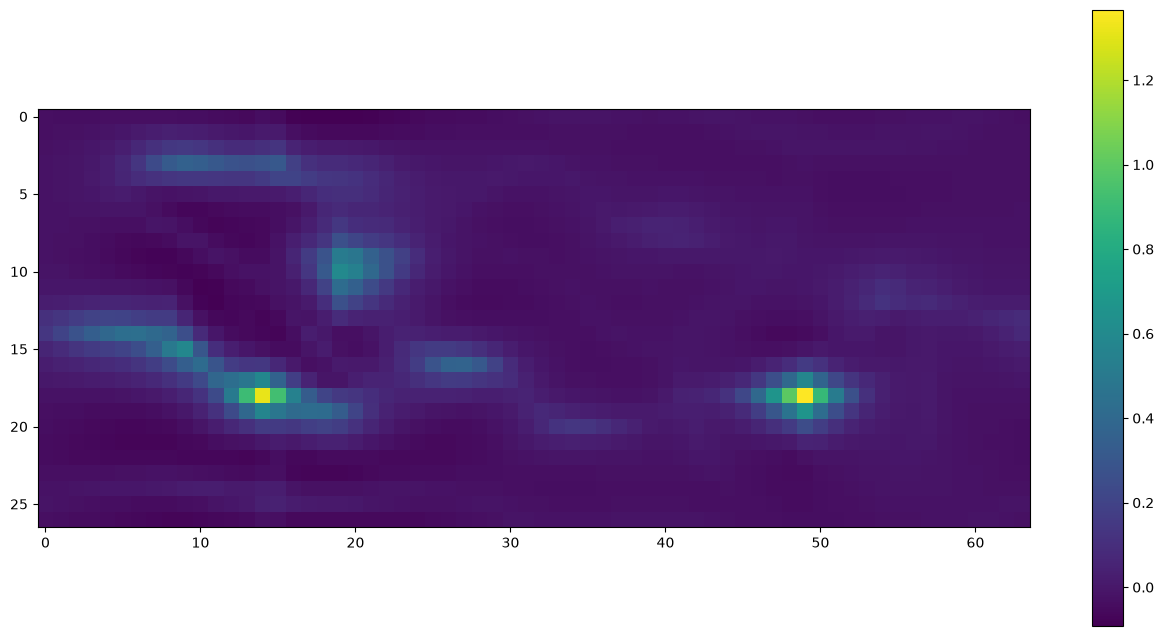

: 

In [ ]:
plt.figure(figsize=(16,8))
# plt.imshow(recon_sm[:,:,70])
plt.imshow(recon_sm[25].T)

plt.colorbar()
plt.show()

In [84]:
cfg = ReconConfig(
    nc=nc, 
    box_size=box_size,
    z_init=30.0,
    z_final=5,
    n_body=True,
    b1=1,
    b2=0,
    galaxy_fac=1.0,
    prior_fac=0.3,
    redshift_fac=1.0,
    anneal_scales=(2.0, 1.0,0),
    maxiter=(20, 10, 20),
    fit_los=False,
    seed=0,
    los_axis=2,
)

rec = Reconstructor(cfg)
rng = np.random.default_rng(42)

truth_linear = rec.forward.sample_linear_field(cfg.seed)
truth_delta = np.asarray(rec.forward.matter_overdensity(truth_linear))
truth_g = np.asarray(galaxy_bias(truth_delta, cfg.b1, cfg.b2))

print(f"truth_linear: shape={truth_linear.shape}")
print(f"truth_delta:  shape={truth_delta.shape}, "
      f"mean={truth_delta.mean():.4f}, std={truth_delta.std():.4f}")
print(f"truth_g:      shape={truth_g.shape}, "
      f"mean={truth_g.mean():.4f}, std={truth_g.std():.4f}")

# quick sanity-check slice

/opt/miniconda3/envs/jax/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype int64 requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


truth_linear: shape=(64, 64, 140)
truth_delta:  shape=(64, 64, 140), mean=0.0000, std=0.7545
truth_g:      shape=(64, 64, 140), mean=0.0000, std=0.7545


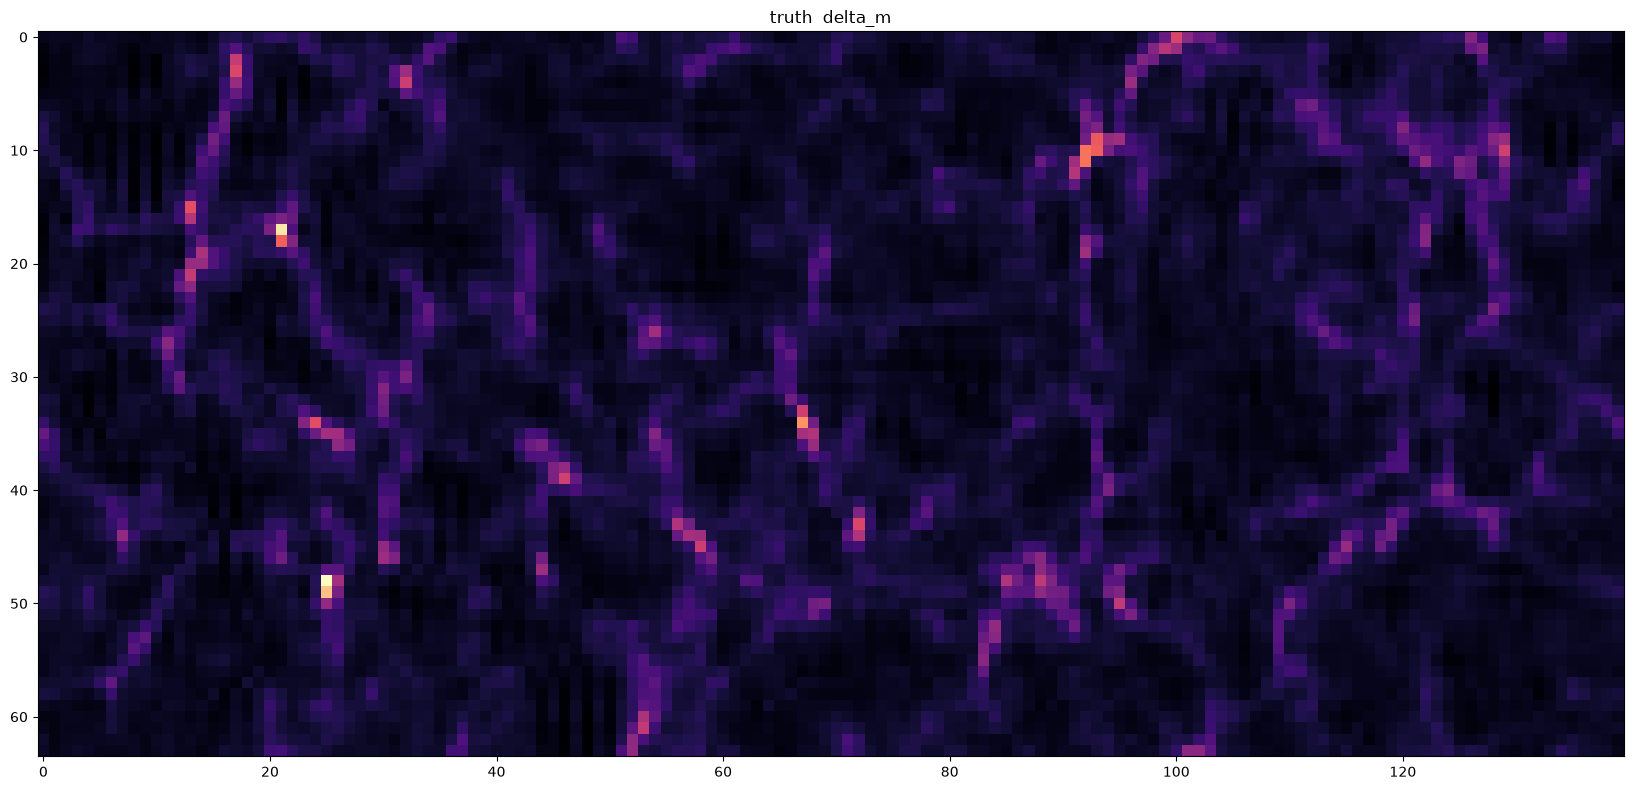

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(20, 8))
ax.imshow(truth_delta[10],cmap="magma")
ax.set_title("truth  delta_m")
# ax[1].imshow(truth_g[10], cmap="magma")
# ax[1].set_title("truth  delta_g")

fig.tight_layout()